# Mandatory Assignment 2 – Hvem vinner LoL-kampen etter 10 minutter?

**Gruppemedlemmer:** Jan Sigurd Engh, Filip Floberg Jensen
, Jonas Palmgren Hesmyr
, Henrik Iversen

**Use case:** Alternativ 4 – eget datasett

**Datasett:** *League of Legends Diamond Ranked Games (10 min)*, Kaggle (bobbyscience).
Filen `high_diamond_ranked_10min.csv` ligger i samme mappe som notebooken og er lastet opp sammen med innleveringen.

**Mål:** Predikere om det blå laget vinner (`blueWins` = 1) eller taper (`blueWins` = 0), kun basert på statistikk fra de første 10 minuttene av kampen.

## 1. Import av biblioteker

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## 2. Last inn og utforsk dataene

In [5]:
df = pd.read_csv("high_diamond_ranked_10min.csv")
print("Rader og kolonner:", df.shape)
df.head()

Rader og kolonner: (9879, 40)


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

In [7]:
print("Manglende verdier totalt:", df.isnull().sum().sum())
print("Dupliserte rader:", df.duplicated().sum())

Manglende verdier totalt: 0
Dupliserte rader: 0


blueWins
0    4949
1    4930
Name: count, dtype: int64


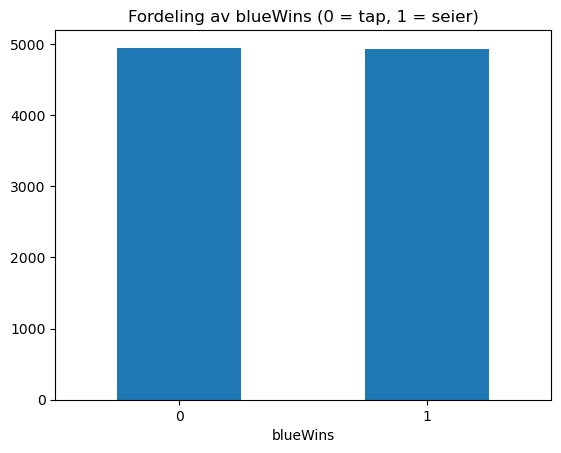

In [8]:
# Er klassene balanserte? (Viktig for å tolke accuracy)
print(df["blueWins"].value_counts())
df["blueWins"].value_counts().plot(kind="bar", title="Fordeling av blueWins (0 = tap, 1 = seier)")
plt.xticks(rotation=0)
plt.show()

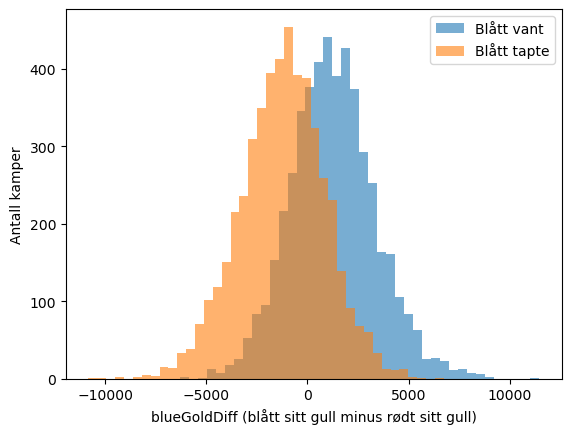

In [9]:
# Henger gullforskjell etter 10 min sammen med hvem som vinner?
plt.hist(df[df["blueWins"] == 1]["blueGoldDiff"], bins=40, alpha=0.6, label="Blått vant")
plt.hist(df[df["blueWins"] == 0]["blueGoldDiff"], bins=40, alpha=0.6, label="Blått tapte")
plt.xlabel("blueGoldDiff (blått sitt gull minus rødt sitt gull)")
plt.ylabel("Antall kamper")
plt.legend()
plt.show()

Klassene er omtrent like store, og de to fordelingene har nesten samme form. Gullforskjellen skiller tydelig: når blått vinner ligger den oftest rundt +1500, og når blått taper rundt −1500. Rundt null overlapper fordelingene, så i jevne kamper er det vanskelig å si hvem som vinner ut fra gull alene.

## 3. Velg features (X) og target (y)

Datasettet har 40 kolonner, men mange sier det samme:
- `gameId` er bare en ID og har ingen verdi for prediksjon.
- Rødt lag er speilvendt av blått lag (f.eks. `redKills` = `blueDeaths`, `redGoldDiff` = −`blueGoldDiff`), så vi bruker bare de blå kolonnene. Diff-kolonnene til blått inneholder allerede informasjon om rødt lag.
- Noen kolonner er bare omregninger av andre (`blueGoldPerMin` = `blueTotalGold` / 10, `blueCSPerMin` = `blueTotalMinionsKilled` / 10, `blueEliteMonsters` = `blueDragons` + `blueHeralds`).

In [12]:
blue_features = [c for c in df.columns if c.startswith("blue") and c != "blueWins"]
redundant = ["blueGoldPerMin", "blueCSPerMin", "blueEliteMonsters"]

features = [c for c in blue_features if c not in redundant]

X = df[features]
y = df["blueWins"]

print(f"{len(features)} features:", features)

16 features: ['blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff']


## 4. Valg av algoritme

Vi bruker logistisk regresjon fordi målet **blueWins** er binært og alle features er numeriske. Modellen er enkel og rask å trene, og den gir en sannsynlighet for seier i stedet for bare ja eller nei. Koeffisientene viser hvilke features som trekker mot seier eller tap, slik at resultatet er lett å tolke. Den fungerer også som et godt utgangspunkt før man eventuelt prøver mer komplekse algoritmer.

## 5. Del opp i trenings- og testdata

In [15]:
# 80 % trening, 20 % test. stratify=y sørger for lik andel seire/tap i begge settene.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Trening:", X_train.shape, " Test:", X_test.shape)

Trening: (7903, 16)  Test: (1976, 16)


## 6. Tren modellen

In [17]:
# StandardScaler setter alle features på samme skala (gull er i tusener, drager er 0 eller 1).
# Det hjelper logistisk regresjon å trene stabilt.
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

## 7. Prediker og evaluer

In [19]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
baseline = y_test.value_counts(normalize=True).max()

print(f"Accuracy:  {accuracy:.1%}")
print(f"Baseline (gjett alltid vanligste utfall): {baseline:.1%}")

Accuracy:  71.9%
Baseline (gjett alltid vanligste utfall): 50.1%


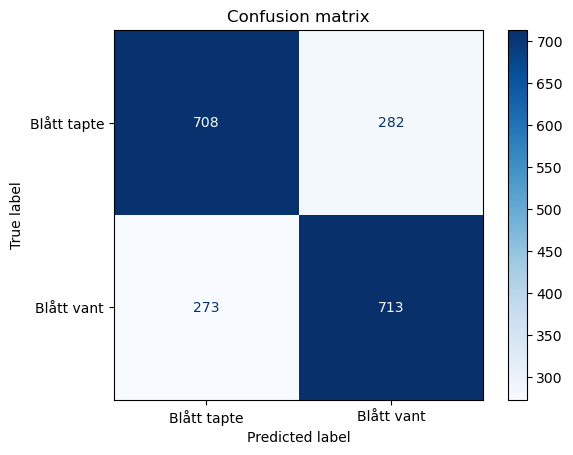

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Blått tapte", "Blått vant"],
    cmap="Blues"
)
plt.title("Confusion matrix")
plt.show()

In [21]:
print(classification_report(y_test, y_pred, target_names=["Blått tapte", "Blått vant"]))

              precision    recall  f1-score   support

 Blått tapte       0.72      0.72      0.72       990
  Blått vant       0.72      0.72      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



### Hva dette forteller oss
Modellen har 708 + 713 = **1421** riktige av 1976 kamper, som gir en accuracy på **72 %**.
Til sammenligning ligger baselinen på ca. 50 %, siden testsettet har nesten like mange seire som tap. Å gjette samme utfall hver gang ville altså bare truffet halvparten, så modellen er klart bedre enn gjetting.
Feilene er også jevnt fordelt: 282 kamper ble feilaktig spådd som seier og 273 som tap. Modellen er dermed ikke partisk mot ett av utfallene.

## 8. Hvilke features betyr mest?

Positive koeffisienter trekker mot seier for blått, negative mot tap. Siden features er skalert, kan størrelsene sammenlignes.
Features som henger tett sammen, f.eks. `blueTotalGold` og `blueGoldDiff` kan gi rare fortegn, fordi modellen "deler" effekten mellom dem.

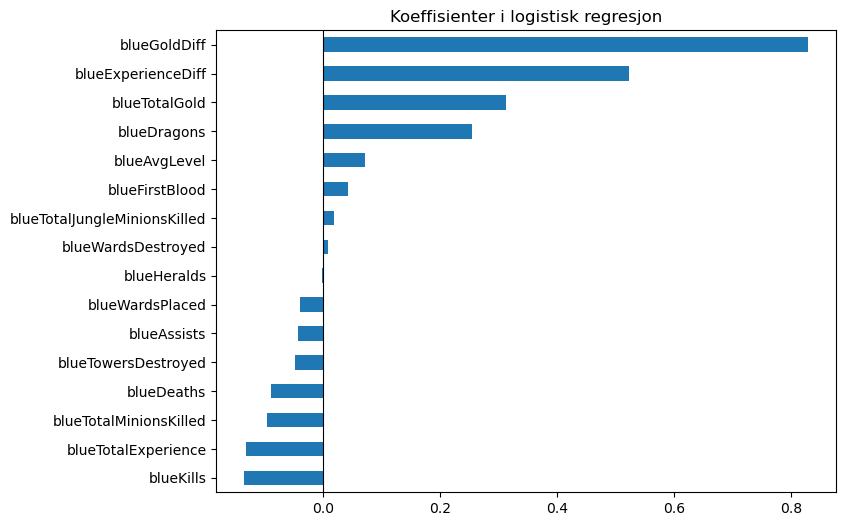

In [24]:
koeff = pd.Series(
    model.named_steps["logisticregression"].coef_[0], index=features
).sort_values()

koeff.plot(kind="barh", figsize=(8, 6), title="Koeffisienter i logistisk regresjon")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

## 9. Demo: prediker en ny kamp

In [26]:
# Start med en "helt vanlig" kamp (medianverdier) og endre noen verdier.
# Denne kan endres helt vilkårlig
ny_kamp = X.median().to_frame().T
ny_kamp["blueGoldDiff"] = 3000
ny_kamp["blueExperienceDiff"] = 1500
ny_kamp["blueDragons"] = 1

sannsynlighet = model.predict_proba(ny_kamp)[0, 1]
print(f"Sannsynlighet for at blått vinner: {sannsynlighet:.0%}")
print("Prediksjon:", "Blått vinner" if model.predict(ny_kamp)[0] == 1 else "Rødt vinner")

Sannsynlighet for at blått vinner: 86%
Prediksjon: Blått vinner


## 10. Konklusjon
Modellen fikk en accuracy på 72 %, som er klart bedre enn baselinen på ca. 50 %. Koeffisientplottet viser at blueGoldDiff og blueExperienceDiff betyr mest for om blått vinner.
Modellen ser bare de første 10 minuttene av kampen, så jevne kamper og comebacks er vanskelige å forutsi. For å forbedre modellen kunne vi prøvd en annen algoritme, som Random Forest, eller fjernet features som henger tett sammen.